In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

# Projeto 3 - Sinais e Sistemas em Tempo Discreto - 2023/01
# Identificação
## Nome: Raul Myron Silva Amorim
## Matrícula: 200049712

# Funções utilizadas.

Coloque abaixo as funções desenvolvidas para este projeto.

In [2]:
def ret(x):
    """Função retângulo definida no enunciado."""
    x = np.atleast_1d(x).astype(float)
    y = np.zeros_like(x)
    y[np.abs(x) < 0.5] = 1
    y[np.abs(x) == 0.5] = 0.5
    return y

def decodifica_dtmf(sinal, Fs=8192):
    """Decodifica um sinal DTMF (touch-fone) em uma string de dígitos."""
    linhas  = [697, 770, 852, 940]
    colunas = [1209, 1336, 1477]
    tabela = {
        (697,1209):'1', (697,1336):'2', (697,1477):'3',
        (770,1209):'4', (770,1336):'5', (770,1477):'6',
        (852,1209):'7', (852,1336):'8', (852,1477):'9',
        (940,1336):'0',
    }
    n_amostras = Fs  # cada tecla dura 1s
    n_teclas = len(sinal)//n_amostras
    numero = ''
    for i in range(n_teclas):
        trecho = sinal[i*n_amostras:(i+1)*n_amostras]
        N = len(trecho)
        X = np.fft.fft(trecho)
        freqs = np.fft.fftfreq(N, d=1/Fs)
        mag = np.abs(X)
        pos = freqs >= 0
        freqs_pos, mag_pos = freqs[pos], mag[pos]

        def energia_perto(f_alvo):
            idx = np.argmin(np.abs(freqs_pos - f_alvo))
            return mag_pos[idx]

        f_linha  = max(linhas,  key=energia_perto)
        f_coluna = max(colunas, key=energia_perto)
        numero += tabela.get((f_linha, f_coluna), '?')
    return numero

# Questão 1

Considere um sinal $x\left(t\right) = 8 \cdot \text{ret}\left(t\right)$, onde:

$$ \begin{align}
	\text{ret}\left(x\right) = \begin{cases}
                               0 & \text{se} ~~ \left|x\right| > \frac{1}{2} \\
															 \frac{1}{2} & \text{se} ~~ \left|x\right| = \frac{1}{2} \\
															 1 & \text{se} ~~ \left|x\right| < \frac{1}{2} \\
                             \end{cases}
\end{align}                             
$$

Considere que o sinal será amostrado a uma taxa $T = \frac{1}{8}$ s, e que queremos uma resolução na frequência de $f_0 = \frac{1}{4}$ Hz. 



## Questão 1a (1.0 ponto)

Obtenha o sinal $x\left[n\right]$, como uma amostragem de $x\left(t\right)$ .

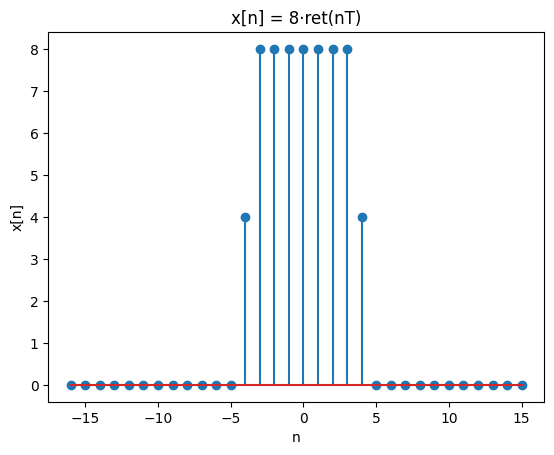

In [3]:
T = 1/8
f0 = 1/4
Fs = 1/T
N = int(Fs/f0)

n = np.arange(-N//2, N//2)
t = n*T
x_n = 8*ret(t)

plt.stem(n, x_n)
plt.title('x[n] = 8·ret(nT)')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.show() 

## Questão 1b (1.0 ponto)

Compare a transformada de Fourier real do sinal $x\left(t\right)$ com a Transformada Discreta de Fourier obtida a partir de $x\left[n\right]$ . 

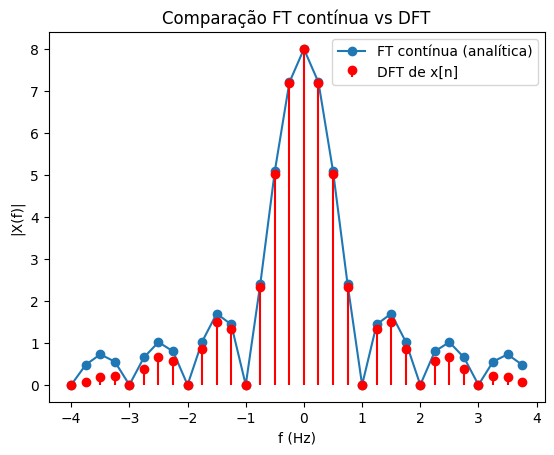

In [4]:
X_dft = np.fft.fftshift(np.fft.fft(x_n)) * T
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=T))

X_analitica = 8*np.sinc(freqs)

plt.plot(freqs, np.abs(X_analitica), 'o-', label='FT contínua (analítica)')
plt.stem(freqs, np.abs(X_dft), linefmt='r-', markerfmt='ro', basefmt=' ', label='DFT de x[n]')
plt.xlabel('f (Hz)')
plt.ylabel('|X(f)|')
plt.legend()
plt.title('Comparação FT contínua vs DFT')
plt.show()

A DFT aproxima bem a Transformada de Fourier contínua na região central (no pico, $|X(0)| = 8$ em ambas, que é a área do pulso), mas diverge nas caudas (erro máximo $\approx 0{,}53$). Duas causas:
 
- **Leakage (vazamento espectral):** o sinal contínuo, de suporte infinito, foi truncado em 4 s. Esse janelamento retangular espalha energia entre bins vizinhos.
- **Aliasing:** a amostragem torna o espectro periódico, e as réplicas vizinhas se somam nas bordas da faixa.
Aumentar o tempo total de aquisição (mais amostras) reduziria o leakage; aumentar a frequência de amostragem $F_s$ afastaria as réplicas, reduzindo o aliasing.

# Questão 2

Considere um sinal $x\left[n\right]$ com $N = 256$ amostras, onde: 
$$
\begin{align}
	x\left[n\right] = \begin{cases}
                               1 & \text{se} ~~ n < 64 \\
															 0 & \text{se} ~~ n \geq 64 \\															 
                             \end{cases}
\end{align}
$$

Considere agora um filtro passa-baixas ideal $H_1$ com frequência de corte normalizada igual a $\frac{1}{16}$.

## Questão 2a (1.0  ponto)

Filtre o sinal $x\left[n\right]$ com o filtro $H_1$, obtendo o sinal $y\left[n\right]$. Compare o sinal original $x\left[n\right]$ com o sinal obtido $y\left[n\right]$. 

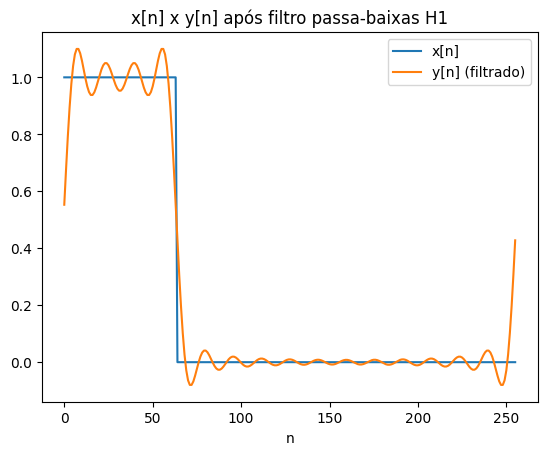

In [8]:
N = 256
n = np.arange(N)
x = np.where(n < 64, 1.0, 0.0)

fc_norm = 1/16
k = np.arange(N)
f_norm = k/N
H1 = np.where((f_norm <= fc_norm) | (f_norm >= 1 - fc_norm), 1.0, 0.0)

X = np.fft.fft(x)
Y = X * H1
y = np.fft.ifft(Y).real

plt.plot(n, x, label='x[n]')
plt.plot(n, y, label='y[n] (filtrado)')
plt.xlabel('n')
plt.legend()
plt.title('x[n] x y[n] após filtro passa-baixas H1')
plt.show()

O degrau abrupto de $x[n]$ vira, em $y[n]$, uma transição suavizada acompanhada de oscilações (*ripples*) — o **fenômeno de Gibbs**, com overshoot medido de $\approx 10\%$ (pico de $1{,}10$).
 
Isso ocorre porque um passa-baixas ideal (retângulo em frequência) corresponde a uma sinc no tempo: ao descartar as altas frequências que "constroem" a borda íngreme, o filtro não consegue mais reproduzir a descontinuidade, gerando as ondulações. O nível DC é preservado (média $0{,}25$ antes e depois), como esperado de um passa-baixas.

## Questão 2b (1.0 ponto)

Compare o espectro do sinal $x\left[n\right]$ com o espectro do sinal $y\left[n\right]$. 

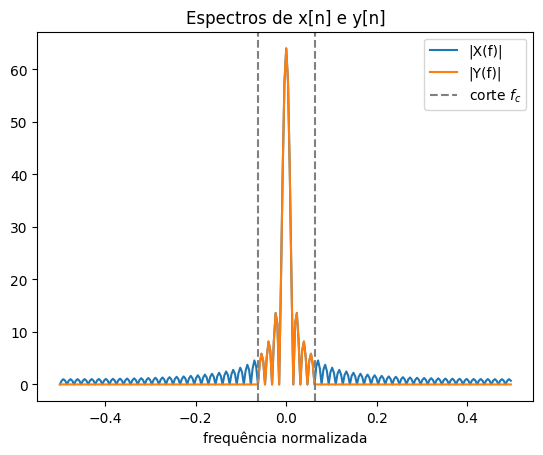

In [9]:
freqs = np.fft.fftshift(np.fft.fftfreq(N))  # em ciclos/amostra

plt.plot(freqs, np.abs(np.fft.fftshift(X)), label='|X(f)|')
plt.plot(freqs, np.abs(np.fft.fftshift(Y)), label='|Y(f)|')
plt.axvline(fc_norm, color='gray', linestyle='--', label='corte $f_c$')
plt.axvline(-fc_norm, color='gray', linestyle='--')
plt.xlabel('frequência normalizada')
plt.legend()
plt.title('Espectros de x[n] e y[n]')
plt.show()

O espectro de $y[n]$ é idêntico ao de $x[n]$ dentro da banda de passagem $|f| \le 1/16$ e **nulo fora dela** — resultado direto do produto $Y = X \cdot H_1$, já que $H_1$ é uma máscara que vale 1 na passagem e 0 na rejeição.
 
Nenhuma frequência da banda de passagem é alterada; apenas as componentes de alta frequência (responsáveis pela borda brusca no domínio do tempo) foram removidas.

## Questão 2c (1.0  ponto)

Aplique o filtro $H_1$ no sinal contido no arquivo "noisy_ecg2.mat". Plote o sinal original e o sinal filtrado, bem como seus espectros.


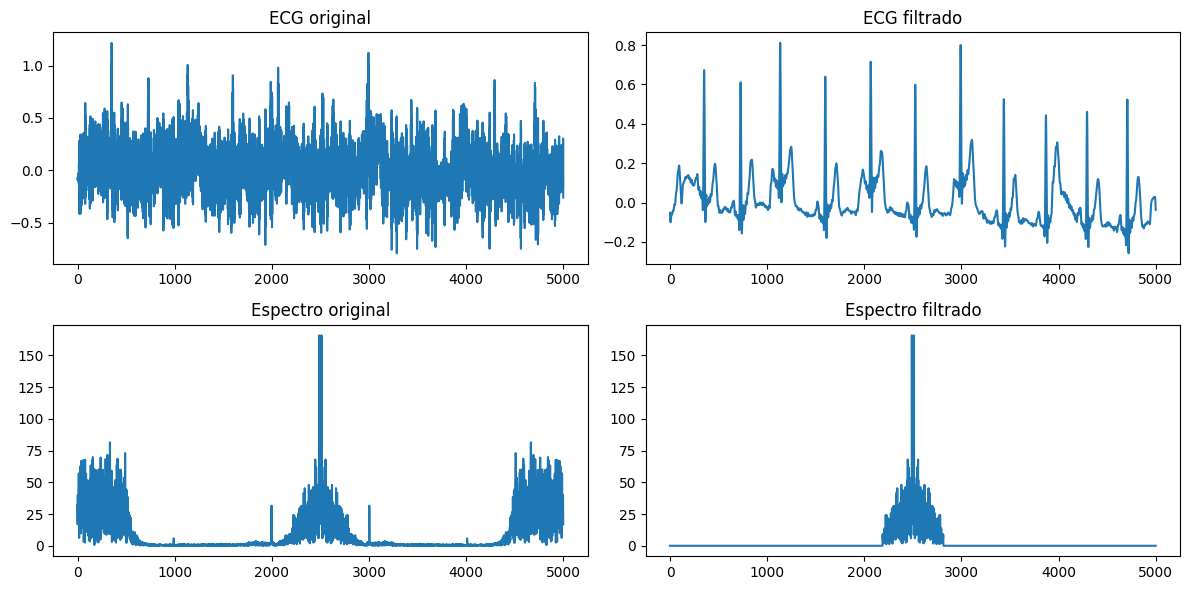

In [10]:
sinal = sp.io.loadmat('noisy_ecg_data_2.mat')['noisy_ecg2'].ravel()

Nc = len(sinal)
kc = np.arange(Nc)
f_normc = kc/Nc
H1c = np.where((f_normc <= fc_norm) | (f_normc >= 1 - fc_norm), 1.0, 0.0)

Sf = np.fft.fft(sinal)
Yf = Sf * H1c
sinal_filtrado = np.fft.ifft(Yf).real

fig, axs = plt.subplots(2, 2, figsize=(12,6))
axs[0,0].plot(sinal); axs[0,0].set_title('ECG original')
axs[0,1].plot(sinal_filtrado); axs[0,1].set_title('ECG filtrado')
axs[1,0].plot(np.abs(np.fft.fftshift(Sf))); axs[1,0].set_title('Espectro original')
axs[1,1].plot(np.abs(np.fft.fftshift(Yf))); axs[1,1].set_title('Espectro filtrado')
plt.tight_layout()
plt.show()

# Questão 3 (5.0 pontos)

O teclado de um touch-fone usa sinais de diferentes frequências para especificar quais botões foram pressionados. O teclado tem 12 botões, em um arranjo de quatro linhas e três colunas. Quando um botão é pressionado um sinal é gerado pela soma de dois tons senoidais com frequências diferentes. A frequência mais alta indica a coluna da tecla pressionada, enquanto a menor frequência indica a linha da tecla pressionada. As frequências são geradas de acordo com a tabela:

| | | Coluna | |
| :-: | :-: | :-: | :-: |
| Linha | 1209 Hz | 1336 Hz | 1477 Hz |
| 697 Hz | 1 | 2 | 3 |
| 770 Hz | 4 | 5 | 6 |
| 852 Hz | 7 | 8 | 9 |
| 940 Hz | | 0 | |

A frequência de amostragem é de 8192 Hz, e o som de cada tecla dura um segundo. Escreva um programa que decodifique, de forma automática, um sinal composto por um número de telefone gerado com essas características. Teste o seu programa com os sinais encontrados no arquivo "touch_fone.mat".


In [11]:
sinal1 = sp.io.loadmat('touch_fone.mat')['x'].ravel()
sinal2 = sp.io.loadmat('touch_fone.mat')['y'].ravel()
sinal3 = sp.io.loadmat('touch_fone.mat')['z'].ravel()

numero1 = decodifica_dtmf(sinal1)
numero2 = decodifica_dtmf(sinal2)
numero3 = decodifica_dtmf(sinal3)

print(f'Número decodificado do sinal x: {numero1}')
print(f'Número decodificado do sinal y: {numero2}')
print(f'Número decodificado do sinal z: {numero3}')

Número decodificado do sinal x: 31075580
Número decodificado do sinal y: 911
Número decodificado do sinal z: 2446712
